# M2 — Fast Weight Programmers

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bdsaglam/bdsaglam.github.io/blob/main/courses/continual-learning/foundations/m2-fast-weight-programmers.ipynb)

**The question:** where do the keys, values, and queries come from?

Second module of the foundations spine. Runs on CPU in seconds; PyTorch from here on.

M1 gave us a memory matrix and the Hebbian write — but it *handed* us the keys, values, and queries. M2 asks where $\mathbf{k},\mathbf{v},\mathbf{q}$ come from. The answer, *a "slow" network writing a "fast" network's weight-memory*, is the first real taste of **nesting**.

## Objective

After this module you should be able to:

- Distinguish **slow weights** (trained by gradient descent, frozen within a forward pass) from **fast weights** (the memory, rewritten every token).
- Explain how the slow weights *program* the fast weights: $\mathbf{k},\mathbf{v},\mathbf{q} = W_k\mathbf{x},\,W_v\mathbf{x},\,W_q\mathbf{x}$, then the outer product $\mathbf{v}\mathbf{k}^\top$ is an "elementary programming instruction" written into $\mathcal{M}$.
- See why this is the seed of **nesting / levels**: one network's outputs become another network's weights, on two timescales. Autograd then sends the loss *back through* the fast memory into the slow weights.
- State the FWP **capacity law** (capacity ≈ key dimension) and how it sets up the feature map (M3) and the delta rule (M4).

## Why it exists (the limitation it fixes)

M1's memory was powerful but *disembodied*: we wrote arbitrary $(\mathbf{k},\mathbf{v})$ pairs by hand. In a real model nobody hands you $\mathbf{k},\mathbf{v},\mathbf{q}$ — they must be **computed from the input**.

And there's a tension already hiding in M1's recurrence $\mathcal{M}_t = \mathcal{M}_{t-1} + \mathbf{v}_t\mathbf{k}_t^\top$: the memory $\mathcal{M}$ changes **every token**, but whatever *produces* $\mathbf{k},\mathbf{v}$ had better be **stable** (learned once, reused across all tokens and all sequences). That's two different timescales living in one layer. Fast Weight Programmers make that split explicit. Naming it is the seed of the whole "levels" idea.

## Core idea — a slow net programs a fast net

Two sets of weights:

- **Slow weights** $W_k, W_v, W_q$ — ordinary trainable weights. Context-independent, changed only by gradient descent *across training*. **Frozen during a forward pass.**
- **Fast weights** $\mathcal{M}$ — the memory. Context-dependent, **regenerated at every timestep** from the input; a short-term memory.

**Where the split comes from.** It is three decades older than the transformer, and it arrived in stages — each one removing something the last still did by hand. Von der Malsburg's *correlation theory of brain function* (1981) proposed that fast, reversible synaptic changes ride on top of slow ones. [Hinton & Plaut (1987)](https://www.cs.toronto.edu/~hinton/absps/fastweights87.pdf) made that a connectionist mechanism: give every connection **two** weights (a slow *plastic* one holding long-term knowledge, a fast *elastic* one holding temporary knowledge that decays toward zero) and use the fast ones to restore memories blurred by later learning. But their fast weights still followed a *hand-designed* rule. [Schmidhuber (1992)](https://people.idsia.ch/~juergen/fastweights/ncfastweightsrev.html) removed that last hand-designed piece, and it is the one this module is about: two feedforward nets, where the first **learns by gradient descent** to produce context-dependent weight changes for the second, whose weights vary quickly. The fast weights stopped being a decay rule and became a *program*.

At each step the slow net projects the input into self-invented patterns and writes their outer product into the fast weights:

$$\mathbf{k}_t,\mathbf{v}_t,\mathbf{q}_t = W_k\mathbf{x}_t,\; W_v\mathbf{x}_t,\; W_q\mathbf{x}_t, \qquad \mathcal{M}_t = \mathcal{M}_{t-1} + \mathbf{v}_t\mathbf{k}_t^\top, \qquad \mathbf{y}_t = \mathcal{M}_t\,\mathbf{q}_t.$$

The name **Fast Weight Programmers**, the reading of those 1990s controllers as writing outer products of self-invented keys and values, and the proof that this *is* linear attention are all [Schlag, Irie & Schmidhuber (2021)](https://arxiv.org/abs/2102.11174) — this module's grounding source, and what M3 and M4 build straight on. Its abstract is the one-liner:

> "a *'slow'* neural net learns by gradient descent to program the *'fast weights'* of another net through sequences of elementary programming instructions which are additive outer products of self-invented activation patterns (today called keys and values)."

The novelty over the classical associative memories of Hebb (1949) and [Hopfield (1982)](https://redwood.berkeley.edu/wp-content/uploads/2018/08/hopfield82.pdf): those associated **pre-wired** patterns; here the slow net **learns to invent** the keys and values it stores (FWP §2). That single shift turns a static associative memory into a *programmable* one: *learned* projections now feed the outer-product memory.

The chain does not stop here. Schmidhuber's next move is a weight matrix that programs *itself*, rather than a second net ([1993](https://link.springer.com/chapter/10.1007/978-1-4471-2063-6_107), "A self-referential weight matrix"); that is where **M5** picks it up.

### Reading

- [FWP](https://arxiv.org/abs/2102.11174) §2 (background on FWPs; Eqs. 1–3, the slow net's outer-product write), §3.1 (Eq. 4, the slow weights generating $\mathbf{k},\mathbf{v},\mathbf{q}$), the abstract for the one-liner, §4.1 (the capacity limitation). The grounding source for this module.
- [Nested Learning](https://arxiv.org/abs/2512.24695) §5 — the same memory read as one of the "existing architectures" the paper unifies.

## 1. From "given $\mathbf{k},\mathbf{v},\mathbf{q}$" to "projected from the input"

The only change from M1: $\mathbf{k},\mathbf{v},\mathbf{q}$ are now $W_k\mathbf{x},\,W_v\mathbf{x},\,W_q\mathbf{x}$. The next cell builds a minimal FWP layer as an `nn.Module` — three `nn.Linear` slow-weight projections and one fast-weight memory tensor. (The `proj_*` linears mirror the real repo's `SelfModifyingLayer` exactly.)

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0)

class FWPLayer(nn.Module):
    """A fast-weight-programmer layer (single head).

    SLOW weights proj_k/proj_v/proj_q (nn.Linear): trainable, FROZEN within a
        forward pass (gradient descent changes them only across training).
    FAST weights M: the memory -- reset per sequence, rewritten every token.
    """
    def __init__(self, d_in, d_key, d_v):
        super().__init__()
        self.proj_k = nn.Linear(d_in, d_key, bias=False)   # slow
        self.proj_v = nn.Linear(d_in, d_v,   bias=False)   # slow
        self.proj_q = nn.Linear(d_in, d_key, bias=False)   # slow
        self.d_key, self.d_v = d_key, d_v

    def forward(self, X):                                   # X: (T, d_in)
        M = torch.zeros(self.d_v, self.d_key)              # fast weights, fresh per sequence
        ys, Mnorms = [], []
        for x in X:
            k = F.normalize(self.proj_k(x), dim=-1)
            v = self.proj_v(x)
            q = F.normalize(self.proj_q(x), dim=-1)
            M = M + torch.outer(v, k)                       # an elementary programming instruction
            ys.append(M @ q); Mnorms.append(M.norm())
        return torch.stack(ys), torch.stack(Mnorms), M

layer = FWPLayer(d_in=8, d_key=16, d_v=8)
X = torch.randn(20, 8)                      # a sequence of 20 tokens, each in R^8
Y, Mnorms, M_final = layer.forward(X)
print("input sequence X:", tuple(X.shape), " -> outputs Y:", tuple(Y.shape))
print("SLOW weights: proj_k", tuple(layer.proj_k.weight.shape),
      "proj_v", tuple(layer.proj_v.weight.shape),
      "proj_q", tuple(layer.proj_q.weight.shape))
print("FAST weights M (final):", tuple(M_final.shape), " |M| =", round(M_final.norm().item(), 2))

input sequence X: (20, 8)  -> outputs Y: (20, 8)
SLOW weights: proj_k (16, 8) proj_v (8, 8) proj_q (16, 8)
FAST weights M (final): (8, 16)  |M| = 14.08


## 2. Two timescales: slow weights frozen, fast weights moving

Within a single forward pass the slow weights never change — only the fast memory $\mathcal{M}$ is rewritten, once per token. Across sequences, $\mathcal{M}$ resets (short-term memory) while the slow weights persist (long-term, learned). The plot shows $\lVert\mathcal{M}_t\rVert$ climbing through a sequence while the slow weights are provably untouched.

slow proj_k unchanged by the forward pass: True


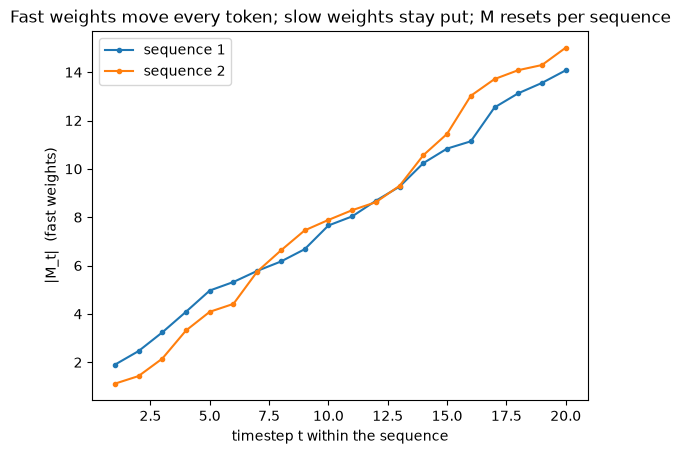

In [13]:
# Slow weights are frozen within a forward pass; only the fast memory moves.
Wk_before = layer.proj_k.weight.detach().clone()
Y, Mnorms, _ = layer.forward(X)
print("slow proj_k unchanged by the forward pass:", torch.equal(Wk_before, layer.proj_k.weight))

# The fast memory is short-term: re-created (reset to 0) on every forward call.
_, Mnorms2, _ = layer.forward(torch.randn(20, 8))            # a different sequence

plt.plot(range(1, 21), Mnorms.detach().numpy(),  marker='o', ms=3, label="sequence 1")
plt.plot(range(1, 21), Mnorms2.detach().numpy(), marker='o', ms=3, label="sequence 2")
plt.xlabel("timestep t within the sequence"); plt.ylabel("|M_t|  (fast weights)")
plt.title("Fast weights move every token; slow weights stay put; M resets per sequence")
plt.legend(); plt.show()

## 3. The programmer view — the seed of nesting

The slow net's **outputs** ($\mathbf{v}_t,\mathbf{k}_t$) become, via the outer product, **changes to another network's weights** ($\mathcal{M}$). So $\mathcal{M}$ is a "fast network" whose weights are *written by* the slow network. One model parameterizes another → **nesting**.

Same slow weights = a fixed *program*; the fast memory it writes is *input-specific*. The next cell runs two different sequences through the **same** layer and shows the resulting memories differ completely — the program is fixed, its state is not.

In [14]:
X1 = torch.randn(20, 8)
X2 = torch.randn(20, 8)
Wk_snapshot = layer.proj_k.weight.detach().clone()
_, _, M1 = layer.forward(X1)
_, _, M2 = layer.forward(X2)
print("slow weights identical across both runs:", torch.equal(Wk_snapshot, layer.proj_k.weight))
rel = ((M1 - M2).norm() / M1.norm()).item()
print(f"yet  ||M1 - M2|| / ||M1|| = {rel:.2f}")
print("=> fixed PROGRAM (slow weights), input-specific STATE (fast weights).")

slow weights identical across both runs: True
yet  ||M1 - M2|| / ||M1|| = 0.73
=> fixed PROGRAM (slow weights), input-specific STATE (fast weights).


### Gradient flows *through* the fast weights (PyTorch autograd)

"Slow weights are trained by gradient descent" hides the interesting part. The loss is computed on the outputs $\mathbf{y}_t = \mathcal{M}_t\mathbf{q}_t$, and $\mathcal{M}_t$ was itself *built from* the slow net's outputs (outer products of $\mathbf{v},\mathbf{k}$). So the training signal must flow **backward through the fast memory** into $W_k,W_v,W_q$.

That back-through-the-memory path is the **inner loop**; gradient descent on the slow weights is the **outer loop**. Two nested loops. Autograd makes the inner one literal. One `loss.backward()` and every slow weight gets a gradient:

In [15]:
layer.zero_grad()
Y, _, _ = layer.forward(torch.randn(20, 8))
loss = Y.pow(2).mean()             # any scalar objective on the outputs
loss.backward()                    # autograd unrolls back THROUGH M into the slow weights
for name, p in layer.named_parameters():
    print(f"{name:15s} grad norm = {p.grad.norm().item():.4f}")
print("=> every SLOW weight receives a gradient: the outer-loop signal reaches them THROUGH M.")

proj_k.weight   grad norm = 0.9462
proj_v.weight   grad norm = 0.8859
proj_q.weight   grad norm = 0.8891
=> every SLOW weight receives a gradient: the outer-loop signal reaches them THROUGH M.


## 4. The capacity law: capacity ≈ key dimension

M1 showed crosstalk grows with stored pairs. FWP makes it **quantitative**: the memory holds about **`d_key` associations** (the dimension of the *projected key*), because that's how many near-orthogonal directions exist to address them. The paper measures exactly this: linear attention with key dim 64 degrades past ~60 associations ([FWP](https://arxiv.org/abs/2102.11174) §6.1.1, Fig. 2).

The next cell reproduces the wall in miniature for a few key dimensions.

**Why this matters for what's next:** capacity is set by the *key* dimension, not the model width. So if you map keys through a **feature map** $\phi(\mathbf{k})$ into a *higher* dimension $d_{\text{dot}}$, you buy capacity for free — that's M3's move (the $\phi$ / DPFP kernel). And *editing* instead of *accumulating* (the **delta rule**) is M4.

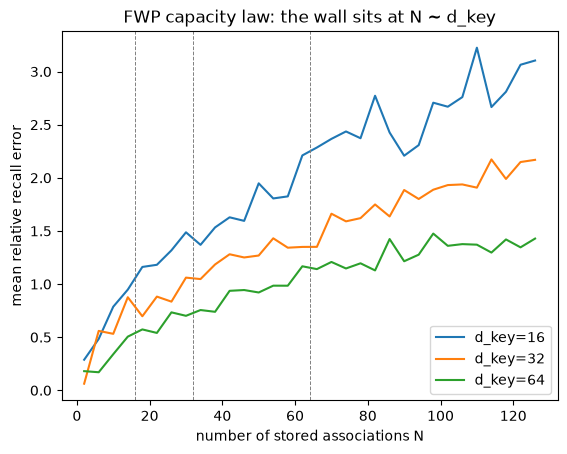

Capacity tracks the KEY dimension. A feature map phi(k) raising d_key buys capacity (M3).


In [16]:
def capacity_curve(d_key, Ns, d_v=8):
    g = torch.Generator().manual_seed(0)
    errs = []
    for N in Ns:
        K = F.normalize(torch.randn(N, d_key, generator=g), dim=1)
        V = torch.randn(N, d_v, generator=g)
        M = V.t() @ K                         # store all N pairs:  M = sum_i v_i k_i^T
        recall = (M @ K.t()).t()              # query with each key:  row j = M k_j
        errs.append(((recall - V).norm(dim=1) / V.norm(dim=1)).mean().item())
    return errs

Ns = list(range(2, 130, 4))
for d_key in (16, 32, 64):
    plt.plot(Ns, capacity_curve(d_key, Ns), label=f"d_key={d_key}")
    plt.axvline(d_key, ls="--", c="gray", lw=0.7)
plt.xlabel("number of stored associations N"); plt.ylabel("mean relative recall error")
plt.title("FWP capacity law: the wall sits at N ~ d_key")
plt.legend(); plt.show()
print("Capacity tracks the KEY dimension. A feature map phi(k) raising d_key buys capacity (M3).")

::: {.callout-note collapse="true"}
## Q: Correlation makes keys non-orthogonal, so we under-use the memory's capacity. Is that also why the paper says additively *stacking* gradients is the wrong optimizer write — and doesn't the same thing hit the gradients flowing back to the slow weights?

One bottleneck — **effective rank** — seen from three sides.

**The core: capacity ≈ effective rank, not $d_{\text{key}}$.** "Crosstalk" is the *symptom* (contaminated recall); the *cause* is **under-used capacity**. The law "capacity $\approx d_{\text{key}}$" silently assumes the keys spread across the whole $d_{\text{key}}$-dimensional space — which random / near-orthogonal keys do. Correlated keys don't: they cluster into an **effective subspace** of dimension $r < d_{\text{key}}$ (the number of significant singular values of the key set). The memory can only separate as many associations as there are independent key directions, so usable capacity $\approx r$. Equivalently, **capacity ≈ rank of the key Gram matrix $KK^\top$**. The cell below makes it literal: provision $d_{\text{key}}=64$, confine the keys to a rank-$r$ subspace, and the wall slides from 64 down to $r$.

**Forward side (the memory).** This is the M1/M2 capacity wall. Fixes: a **feature map $\phi$** (M3) — which helps *twice*: it raises the nominal dimension $d_{\text{dot}}$ *and* spreads correlated inputs into more orthogonal directions (DPFP's combinatorial ReLU features; key whitening does the same), recovering effective rank — and the **delta write** (M4), which edits instead of stacking.

**Optimizer side (the DGD intuition — yes).** The [Nested Learning paper](https://arxiv.org/abs/2512.24695) reframes *gradient descent itself* as an associative memory (§3.1 Eq 8; §4.1 Eqs 29–30) — this whole callout draws on NL: one step writes an outer product with **key = layer input $\mathbf{x}_t$** and **value = output surprise $\boldsymbol{\delta}_t$**, i.e. $\partial\mathcal{L}/\partial W_\ell = \boldsymbol{\delta}_\ell\hat{\mathbf{x}}_{\ell-1}^\top$. Same additive write ⇒ same effective-rank limitation: on **correlated / non-i.i.d.** inputs the stacked updates interfere, "resulting in slower (or less robust) convergence" (§4.2). The fix is **DGD** (§4.5) — a state-aware delta-rule write "capturing the dependencies of data samples **without i.i.d. assumption**" (§1.2). Two precisions: (i) the "sequence" is the **data / gradient stream** across optimizer steps, not back-prop-through-*time*; (ii) the paper insists **backprop $\neq$ pure Hebbian / linear attention** — the value $\boldsymbol{\delta}_t$ is **self-generated** (depends on the current $W_t$), making GD a *self-referential* process (Schmidhuber 1993), which is what DGD / GGD formalize.

**Backward / BPTT side (the distinction to hold).** Gradients flowing through the inner loop into the slow weights *are* a sum of correlated per-timestep terms — but that's a **different** effect. Summing correlated gradients still gives the **correct** gradient (gradient of a sum = sum of gradients); correlation only makes it **anisotropic / ill-conditioned**, and recall itself stays clean. The cure is **preconditioning** (Adam / Muon / natural gradient / DGD), the optimizer's job (M6), which the architecture leaves untouched. And BPTT isn't special: unrolling the inner loop or using the equivalent parallel / chunked form gives the *identical* gradient, so the unroll adds no extra crosstalk — it just generates the stream the optimizer must precondition. (The additive recurrence $\mathcal{M}_t=\mathcal{M}_{t-1}+\mathbf{v}_t\mathbf{k}_t^\top$ has state-Jacobian $\partial\mathcal{M}_t/\partial\mathcal{M}_{t-1}=I$, so gradients pass through cleanly — no vanish/explode — which is *why* FWP is parallel-trainable.)

**The unifying point.** **Effective rank is the single quantity** behind both faces: low effective rank = the forward capacity wall *and* the ill-conditioned key Gram that skews the gradient. They are repaired in different places — $\phi$ / decorrelation + delta write on the forward side (M3/M4), preconditioning optimizers on the backward side (M6). And this is exactly the paper's case for **architecture-specific optimizers** (§6): "architecture generates the context for optimizers (i.e., gradients). Therefore, the proper memory management of gradients (i.e., optimization algorithm) relies on the choice of architectures … we need to design architecture specific optimizers." The architecture shapes the gradient distribution; the optimizer should be matched to it.

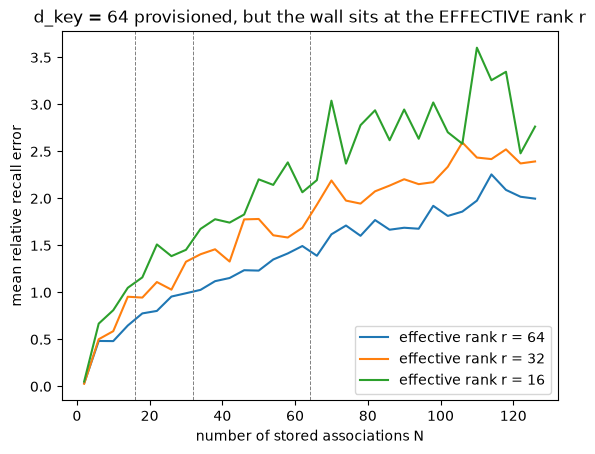

Correlated keys -> low effective rank -> the d_key capacity is underused; the wall tracks r, not d_key.


In [17]:
# Provision d_key = 64, but confine keys to an EFFECTIVE subspace of rank r < d_key.
# Usable capacity then tracks r, not d_key: the provisioned capacity is underused.
def capacity_curve_rank(d_key, rank_r, Ns, d_v=8):
    g = torch.Generator().manual_seed(0)
    errs = []
    for N in Ns:
        basis = F.normalize(torch.randn(rank_r, d_key, generator=g), dim=1)  # (r, d_key) subspace
        coeff = torch.randn(N, rank_r, generator=g)                          # (N, r) coordinates
        K = F.normalize(coeff @ basis, dim=1)                                # (N, d_key), rank r
        V = torch.randn(N, d_v, generator=g)
        M = V.t() @ K
        recall = (M @ K.t()).t()
        errs.append(((recall - V).norm(dim=1) / V.norm(dim=1)).mean().item())
    return errs

Ns = list(range(2, 130, 4))
d_key = 64
for r in (64, 32, 16):
    plt.plot(Ns, capacity_curve_rank(d_key, r, Ns), label=f"effective rank r = {r}")
    plt.axvline(r, ls="--", c="gray", lw=0.7)
plt.xlabel("number of stored associations N"); plt.ylabel("mean relative recall error")
plt.title("d_key = 64 provisioned, but the wall sits at the EFFECTIVE rank r")
plt.legend(); plt.show()
print("Correlated keys -> low effective rank -> the d_key capacity is underused; the wall tracks r, not d_key.")

:::

## Code walkthrough — slow vs fast weights in real code

Our `FWPLayer` is a deliberate miniature of [`train_hope.py`](https://github.com/obekt/HOPE-nested-learning/blob/main/train_hope.py) → `SelfModifyingLayer`:

```python
self.proj_q = nn.Linear(dim, dim)   # \
self.proj_k = nn.Linear(dim, dim)   #  >  SLOW weights (trained by gradient descent)
self.proj_v = nn.Linear(dim, dim)   # /
...
q, k, v = self.proj_q(x), self.proj_k(x), self.proj_v(x)   # slow net invents k, v, q
memory = a_t * memory + update                              # FAST weights (rewritten per token)
```

The `proj_*` linears are the **slow weights**; `memory` is the **fast weights** — identical roles to our toy. The other reproduction, [kmccleary3301/nested_learning](https://github.com/kmccleary3301/nested_learning), keeps the split too ([`fast_state.py`](https://github.com/kmccleary3301/nested_learning/blob/main/src/nested_learning/fast_state.py) holds the fast memory; the projections live in the block).

The FWP paper's own code is [`ischlag/fast-weight-transformers`](https://github.com/ischlag/fast-weight-transformers/tree/main/synthetic): [`linearAttention.py`](https://github.com/ischlag/fast-weight-transformers/blob/main/synthetic/linearAttention.py) (the FWP), [`softmaxAttention.py`](https://github.com/ischlag/fast-weight-transformers/blob/main/synthetic/softmaxAttention.py) (the baseline), and [`associativeRetrievalDataset.py`](https://github.com/ischlag/fast-weight-transformers/blob/main/synthetic/associativeRetrievalDataset.py) — the capacity task we miniaturized in §4.

## Exit check

Ready for M3 when you can:

1. Name which weights are "slow" vs "fast" in $\;\mathbf{k},\mathbf{v},\mathbf{q} = W_k\mathbf{x},W_v\mathbf{x},W_q\mathbf{x};\ \ \mathcal{M}_t = \mathcal{M}_{t-1}+\mathbf{v}_t\mathbf{k}_t^\top;\ \ \mathbf{y}_t=\mathcal{M}_t\mathbf{q}_t$ — and what trains each.
2. Explain why "a slow net writes a fast net's weights" is *nesting*, and which timescale each loop runs on (the autograd cell shows the inner loop literally).
3. State the capacity law and how a feature map $\phi$ raises capacity.

**Next → M3, Linear attention = fast weights.** We've built the FWP; M3 proves it *is* linear attention in full — the $O(N)$ vs $O(N^2)$ story, the kernel / feature map $\phi$, and the recurrent-vs-parallel forms — turning the sketch from M1's §4 callout into the complete architecture picture.